In [3]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor


In [4]:
data = pd.read_csv('pone.0300127.s001.csv')
demographic_data = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Subject_Demographics/Demographics_09Oct2025.csv')
family_history = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Family_History_09Oct2025.csv')

In [7]:
data.head()

,PATNO,COHORT,COHORT_DEFINITION,ENROLL_DATE,ENROLL_STATUS,STATUS_DATE,SCREENEDAM,ENROLL_AGE,INEXPAGE,AV133STDY,TAUSTDY,GAITSTDY,PISTDY,SV2ASTDY,NXTAUSTDY,DATELIG,PPMI_ONLINE_ENROLL,ENRLPINK1,ENRLPRKN,ENRLSRDC,ENRLNORM,ENRLOTHGV,ENRLHPSM,ENRLRBD,ENRLLRRK2,ENRLSNCA,ENRLGBA
0,3000,2,Healthy Control,02/2011,Withdrew,10/2024,NaN,69.1,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NO,0.0,0.0,0.0,NaN,NaN,0,0,0,0,0
1,3001,1,Parkinson's Disease,03/2011,Enrolled,09/2021,NaN,65.1,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NO,0.0,0.0,1.0,NaN,NaN,0,0,0,0,0
2,3002,1,Parkinson's Disease,03/2011,Withdrew,10/2024,NaN,67.6,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NO,0.0,0.0,1.0,NaN,NaN,0,0,0,0,0
3,3003,1,Parkinson's Disease,04/2011,Enrolled,01/2022,NaN,56.7,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,YES,0.0,0.0,1.0,NaN,NaN,0,0,0,0,0
4,3004,2,Healthy Control,04/2011,Enrolled,01/2022,NaN,59.4,NaN,0.0,0.0,1.0,0.0,0.0,0.0,NaN,YES,0.0,0.0,0.0,NaN,NaN,0,0,0,0,0


In [9]:
df1=data[data['COHORT']==1]

In [11]:
df2=df1[(df1['ENROLL_STATUS']=='Enrolled') | (df1['ENROLL_STATUS']=='Complete') | (df1['ENROLL_STATUS']=='Withdraw Deceased')]

In [13]:
patient_data = df2[['PATNO','COHORT_DEFINITION','ENROLL_STATUS']]


In [15]:
demographic_data.head()

,REC_ID,PATNO,EVENT_ID,PAG_NAME,INFODT,AFICBERB,ASHKJEW,BASQUE,BIRTHDT,SEX,CHLDBEAR,HOWLIVE,GAYLES,HETERO,BISEXUAL,PANSEXUAL,ASEXUAL,OTHSEXUALITY,HANDED,HISPLAT,RAASIAN,RABLACK,RAHAWOPI,RAINDALS,RANOS,RAWHITE,RAUNKNOWN,ORIG_ENTRY,LAST_UPDATE
0,IA86904,3000,TRANS,SCREEN,01/2011,0.0,0.0,0.0,12/1941,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,01/2011,2022-11-07 00:00:00.0
1,IA86905,3001,TRANS,SCREEN,02/2011,0.0,0.0,0.0,01/1946,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,02/2011,2022-11-07 00:00:00.0
2,IA86906,3002,TRANS,SCREEN,03/2011,0.0,0.0,0.0,08/1943,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,03/2011,2022-11-07 00:00:00.0
3,IA86907,3003,TRANS,SCREEN,03/2011,0.0,0.0,0.0,07/1954,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,03/2011,2022-11-07 00:00:00.0
4,IA86908,3004,TRANS,SCREEN,03/2011,0.0,0.0,0.0,11/1951,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,03/2011,2022-11-07 00:00:00.0


In [17]:
import pandas as pd
import numpy as np


merged = patient_data.merge(demographic_data, on='PATNO', how='left')

race_cols = ['RAASIAN','RABLACK','RAHAWOPI','RAINDALS','RANOS','RAWHITE','RAUNKNOWN']
race_map = {
    'RAASIAN':   'Asian',
    'RABLACK':   'Black or African American',
    'RAHAWOPI':  'Native Hawaiian or Other Pacific Islander',
    'RAINDALS':  'American Indian or Alaska Native',
    'RANOS':     'Not Otherwise Specified',
    'RAWHITE':   'White',
    'RAUNKNOWN': 'Unknown'
}

def infer_race(row):
    flags = {col: (1 if pd.notna(row.get(col)) and float(row[col]) == 1.0 else 0) for col in race_cols}
    on_cols = [race_map[c] for c, v in flags.items() if v == 1]
    if len(on_cols) == 0:
        return 'Unknown'
    if len(on_cols) == 1:
        return on_cols[0]
    return 'Multiple'

merged['RACE'] = merged.apply(infer_race, axis=1)

Demo_df = merged[['PATNO', 'BIRTHDT', 'RACE', 'SEX']].reset_index(drop=True)
Demo_df.head()


,PATNO,BIRTHDT,RACE,SEX
0,3001,01/1946,White,1.0
1,3003,07/1954,White,0.0
2,3010,06/1964,White,1.0
3,3012,01/1953,White,1.0
4,3018,09/1951,White,0.0


In [19]:

anyfam_bin = (
    family_history['ANYFAMPD']
      .fillna(0)
      .gt(0)
      .astype(int)
)

anyfam_by_pat = (
    family_history.assign(ANYFAMPD_bin=anyfam_bin)
      .groupby('PATNO',as_index=False)['ANYFAMPD_bin']
      .max()
      .rename(columns={'ANYFAMPD_bin':'FamilyHistory'})
)

anyfam_by_pat.head(10)
data1 = Demo_df.merge(anyfam_by_pat, on='PATNO', how='left')
data1.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory
0,3001,01/1946,White,1.0,0.0
1,3003,07/1954,White,0.0,0.0
2,3010,06/1964,White,1.0,1.0
3,3012,01/1953,White,1.0,0.0
4,3018,09/1951,White,0.0,1.0


In [21]:
pd_diagnosis_history = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/PD_Diagnosis_History_22Oct2025.csv')

In [85]:
diagnosis=pd_diagnosis_history[['PATNO','PDDXDT','DXTREMOR','DXRIGID','DXBRADY','DXOTHSX','DOMSIDE']]
diagnosis.head()

,PATNO,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE
0,3001,04/2010,1.0,1.0,1.0,0.0,2.0
1,3002,02/2010,1.0,0.0,1.0,1.0,1.0
2,3003,03/2009,0.0,1.0,1.0,1.0,2.0
3,3005,NaN,NaN,NaN,NaN,NaN,NaN
4,3006,11/2010,1.0,1.0,1.0,0.0,2.0


In [87]:
data2=data1.merge(diagnosis, on ='PATNO', how = 'left')
data2.shape

(1173, 11)

In [89]:
dopamine_theraphy_data = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/Initiation_of_Dopaminergic_Therapy_22Oct2025.csv')
dopamine_flag = (
    dopamine_theraphy_data.groupby('PATNO', as_index=False)['DOPTHERST']
    .max()
)
data3= data2.merge(dopamine_flag, on ='PATNO',how ='left')
data3.shape

(1173, 12)

In [91]:
montreal_cognitive_Ass = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/Montreal_Cognitive_Assessment__MoCA__22Oct2025.csv')
montreal_cognitive_Ass['INFODT_parsed'] = pd.to_datetime(montreal_cognitive_Ass['INFODT'], format='%m/%Y', errors='coerce')
# mcascore = (
#     montreal_cognitive_Ass.sort_values(['PATNO', 'INFODT_parsed'])
#     .groupby('PATNO', as_index=False)
#     .tail(1)
# )

tmp = (
    montreal_cognitive_Ass
      .sort_values(['PATNO', 'INFODT_parsed'], ascending=[True, True])
      .assign(MCATOT_latest=lambda d: d.groupby('PATNO')['MCATOT'].ffill())
)

mcascore = (
    tmp.groupby('PATNO', as_index=False)
       .tail(1)[['PATNO', 'MCATOT_latest']]
       .rename(columns={'MCATOT_latest': 'MCATOT'})
)

data4 = data3.merge(mcascore, on='PATNO', how='left')
data4 = data3.merge(mcascore[['PATNO','MCATOT']], on ='PATNO', how='left')
data4.head()


,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE,DOPTHERST,MCATOT
0,3001,01/1946,White,1.0,0.0,04/2010,1.0,1.0,1.0,0.0,2.0,NaN,29.0
1,3003,07/1954,White,0.0,0.0,03/2009,0.0,1.0,1.0,1.0,2.0,1.0,28.0
2,3010,06/1964,White,1.0,1.0,02/2011,0.0,1.0,1.0,0.0,1.0,0.0,29.0
3,3012,01/1953,White,1.0,0.0,08/2011,1.0,1.0,1.0,1.0,2.0,NaN,26.0
4,3018,09/1951,White,0.0,1.0,01/2012,1.0,1.0,2.0,0.0,2.0,1.0,23.0


In [93]:
freezing_fall = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/Determination_of_Freezing_and_Falls_22Oct2025.csv')
freezing_fall['INFODT_parsed'] = pd.to_datetime(freezing_fall['INFODT'], format='%m/%Y', errors='coerce')

latest_rows = (
    freezing_fall
    .sort_values(['PATNO', 'INFODT_parsed'])
    .groupby('PATNO', as_index=False)
    .tail(1)
)
latest_frz = latest_rows[['PATNO', 'FRZGT12M','FLNFR12M']].reset_index(drop=True)
other_cols = [
    'INJFRHIP','INJFRUE','INJFRSKL','INJFROTH',
    'HINJNOLC','HINJLOC2','INJSTCH','INJOTH',
    'FLLDRVIS','FLLERVIS','FLLHOSP','FLLSURG','FLLINST'
]

agg_other = (
    freezing_fall
    .fillna(0)
    .groupby('PATNO', as_index=False)[other_cols]
    .max()
)

freeze_combined = latest_frz.merge(agg_other, on='PATNO', how='outer')
data5 = data4.merge(freeze_combined, on='PATNO', how='left')
print(data5.shape)



(1173, 28)


In [1]:
import pandas as pd

df = freezing_fall.copy()


# Make sure INFODT_parsed is datetime already. If not, uncomment:
# df['INFODT_parsed'] = pd.to_datetime(df['INFODT'], format='%m/%Y', errors='coerce')

def pick_row_for_patient(patient_df):
    # sort once so "latest" is easy
    patient_df = patient_df.sort_values('INFODT_parsed')

    # 1. Most recent date for this patient
    latest_date = patient_df['INFODT_parsed'].max()
    latest_year = latest_date.year

    # 2. Which years does this patient have data for?
    years_present = set(patient_df['INFODT_parsed'].dt.year.dropna())

    # 3. Check continuous 3-year coverage: Y, Y-1, Y-2
    required_years = {latest_year, latest_year - 1, latest_year - 2}
    has_continuous_3yr = required_years.issubset(years_present)

    if has_continuous_3yr:
        # Keep only rows from those 3 required years
        recent_window = patient_df[
            patient_df['INFODT_parsed'].dt.year.isin(required_years)
        ]

        # Pick row with highest FRZGT12M, break ties by most recent date
        best_row = (
            recent_window
            .sort_values(
                by=['FLNFR12M', 'INFODT_parsed'],
                ascending=[False, False]
            )
            .iloc[0]
        )
    else:
        # Fall back to just the single latest row overall
        best_row = (
            patient_df
            .sort_values('INFODT_parsed', ascending=False)
            .iloc[0]
        )

    return best_row

# Apply per patient
best_rows = (
    df.fillna(0).groupby('PATNO', group_keys=False)
      .apply(pick_row_for_patient)
      .reset_index(drop=True)
)
best_rows=best_rows[['PATNO', 'FRZGT12M','FLNFR12M',
    'INJFRHIP','INJFRUE','INJFRSKL','INJFROTH',
    'HINJNOLC','HINJLOC2','INJSTCH','INJOTH',
    'FLLDRVIS','FLLERVIS','FLLHOSP','FLLSURG','FLLINST','INFODT_parsed']]
data5 = data4.merge(best_rows, on ='PATNO', how='left')
data5.head()


NameError: name 'freezing_fall' is not defined

In [96]:
scopa = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/SCOPA-AUT_22Oct2025.csv')
scopa['INFODT_parsed'] = pd.to_datetime(scopa['INFODT'], format='%m/%Y', errors='coerce')

scopa_aut = (
    scopa.sort_values(['PATNO', 'INFODT_parsed'])
      .groupby('PATNO', as_index=False)
      .tail(1)
)
scopa_latest=scopa_aut[['PATNO','SCAU14','SCAU16']].reset_index(drop=True)
data6=data5.merge(scopa_latest, on='PATNO', how='left')
data6.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE,DOPTHERST,MCATOT,FRZGT12M,FLNFR12M,INJFRHIP,INJFRUE,INJFRSKL,INJFROTH,HINJNOLC,HINJLOC2,INJSTCH,INJOTH,FLLDRVIS,FLLERVIS,FLLHOSP,FLLSURG,FLLINST,INFODT_parsed,SCAU14,SCAU16
0,3001,01/1946,White,1.0,0.0,04/2010,1.0,1.0,1.0,0.0,2.0,NaN,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2023-03-01,1.0,0.0
1,3003,07/1954,White,0.0,0.0,03/2009,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01,1.0,0.0
2,3010,06/1964,White,1.0,1.0,02/2011,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2025-06-01,1.0,0.0
3,3012,01/1953,White,1.0,0.0,08/2011,1.0,1.0,1.0,1.0,2.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1.0,0.0
4,3018,09/1951,White,0.0,1.0,01/2012,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2025-06-01,1.0,0.0


In [99]:
neuro_QoL=pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/Neuro_QoL__Lower_Extremity_Function__Mobility__-_Short_Form_22Oct2025.csv')


neuro_QoL['INFODT_parsed'] = pd.to_datetime(neuro_QoL['INFODT'], format='%m/%Y', errors='coerce')

latest_rows = (
    neuro_QoL.sort_values(['PATNO', 'INFODT_parsed'])
      .groupby('PATNO', as_index=False)
      .tail(1)
)
nqmob37_latest = latest_rows[['PATNO', 'NQMOB37','NQMOB30','NQMOB26','NQMOB32','NQMOB33','NQMOB31','NQMOB28']].reset_index(drop=True)
data7=data6.merge(nqmob37_latest, on ='PATNO', how='left')
data7.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE,DOPTHERST,MCATOT,FRZGT12M,FLNFR12M,INJFRHIP,INJFRUE,INJFRSKL,INJFROTH,HINJNOLC,HINJLOC2,INJSTCH,INJOTH,FLLDRVIS,FLLERVIS,FLLHOSP,FLLSURG,FLLINST,INFODT_parsed,SCAU14,SCAU16,NQMOB37,NQMOB30,NQMOB26,NQMOB32,NQMOB33,NQMOB31,NQMOB28
0,3001,01/1946,White,1.0,0.0,04/2010,1.0,1.0,1.0,0.0,2.0,NaN,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2023-03-01,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0
1,3003,07/1954,White,0.0,0.0,03/2009,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0
2,3010,06/1964,White,1.0,1.0,02/2011,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0
3,3012,01/1953,White,1.0,0.0,08/2011,1.0,1.0,1.0,1.0,2.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3018,09/1951,White,0.0,1.0,01/2012,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0


In [101]:
geriatric_depression = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/Geriatric_Depression_Scale__Short_Version__22Oct2025.csv')
flip_cols = ['GDSSATIS', 'GDSGSPIR', 'GDSHAPPY', 'GDSALIVE', 'GDSENRGY']

for c in flip_cols:
    geriatric_depression[c] = geriatric_depression[c].where(geriatric_depression[c].isna(), 1 - geriatric_depression[c].astype(float))

sum_cols = [
    'GDSSATIS','GDSDROPD','GDSEMPTY','GDSBORED','GDSGSPIR','GDSAFRAD',
    'GDSHAPPY','GDSHLPLS','GDSHOME','GDSMEMRY','GDSALIVE','GDSWRTLS',
    'GDSENRGY','GDSHOPLS','GDSBETER'
]

geriatric_depression['Total Depression Score'] = geriatric_depression[sum_cols].sum(axis=1, skipna=True).astype(float)
geriatric_depressionScore = (
    geriatric_depression.groupby('PATNO', as_index=False)['Total Depression Score']
    .max()
)
# geriatric_depression = geriatric_depression[geriatric_depression['EVENT_ID']=='BL']
scale_score = ['PATNO', 'Total Depression Score']
data8=data7.merge(geriatric_depressionScore[scale_score], on ='PATNO', how='left')
data8.head(5)

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE,DOPTHERST,MCATOT,FRZGT12M,FLNFR12M,INJFRHIP,INJFRUE,INJFRSKL,INJFROTH,HINJNOLC,HINJLOC2,INJSTCH,INJOTH,FLLDRVIS,FLLERVIS,FLLHOSP,FLLSURG,FLLINST,INFODT_parsed,SCAU14,SCAU16,NQMOB37,NQMOB30,NQMOB26,NQMOB32,NQMOB33,NQMOB31,NQMOB28,Total Depression Score
0,3001,01/1946,White,1.0,0.0,04/2010,1.0,1.0,1.0,0.0,2.0,NaN,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2023-03-01,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0
1,3003,07/1954,White,0.0,0.0,03/2009,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0
2,3010,06/1964,White,1.0,1.0,02/2011,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0
3,3012,01/1953,White,1.0,0.0,08/2011,1.0,1.0,1.0,1.0,2.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0
4,3018,09/1951,White,0.0,1.0,01/2012,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0


In [103]:
data8.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE,DOPTHERST,MCATOT,FRZGT12M,FLNFR12M,INJFRHIP,INJFRUE,INJFRSKL,INJFROTH,HINJNOLC,HINJLOC2,INJSTCH,INJOTH,FLLDRVIS,FLLERVIS,FLLHOSP,FLLSURG,FLLINST,INFODT_parsed,SCAU14,SCAU16,NQMOB37,NQMOB30,NQMOB26,NQMOB32,NQMOB33,NQMOB31,NQMOB28,Total Depression Score
0,3001,01/1946,White,1.0,0.0,04/2010,1.0,1.0,1.0,0.0,2.0,NaN,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2023-03-01,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0
1,3003,07/1954,White,0.0,0.0,03/2009,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0
2,3010,06/1964,White,1.0,1.0,02/2011,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0
3,3012,01/1953,White,1.0,0.0,08/2011,1.0,1.0,1.0,1.0,2.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0
4,3018,09/1951,White,0.0,1.0,01/2012,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0


In [105]:
MDS_UPDRS=pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/MDS-UPDRS_Part_IV__Motor_Complications_22Oct2025.csv')


MDS_UPDRS['INFODT_parsed'] = pd.to_datetime(MDS_UPDRS['INFODT'], format='%m/%Y', errors='coerce')

latest_rows_updrs = (
    MDS_UPDRS.groupby('PATNO', as_index=False)['NP4TOT']
    .max()
)
MDS_UPDRS_latest = latest_rows_updrs[['PATNO', 'NP4TOT']].reset_index(drop=True)
data9=data8.merge(MDS_UPDRS_latest, on ='PATNO', how='left')
data9.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE,DOPTHERST,MCATOT,FRZGT12M,FLNFR12M,INJFRHIP,INJFRUE,INJFRSKL,INJFROTH,HINJNOLC,HINJLOC2,INJSTCH,INJOTH,FLLDRVIS,FLLERVIS,FLLHOSP,FLLSURG,FLLINST,INFODT_parsed,SCAU14,SCAU16,NQMOB37,NQMOB30,NQMOB26,NQMOB32,NQMOB33,NQMOB31,NQMOB28,Total Depression Score,NP4TOT
0,3001,01/1946,White,1.0,0.0,04/2010,1.0,1.0,1.0,0.0,2.0,NaN,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2023-03-01,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0
1,3003,07/1954,White,0.0,0.0,03/2009,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0
2,3010,06/1964,White,1.0,1.0,02/2011,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0
3,3012,01/1953,White,1.0,0.0,08/2011,1.0,1.0,1.0,1.0,2.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,5.0
4,3018,09/1951,White,0.0,1.0,01/2012,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0


In [107]:
vital_data = pd.read_csv('/Users/sowjanyapadala/Desktop/Coursework/PD_project/RecentData/Data_with actual dates/Vital_Signs_08Oct2025.csv')

vital_data['DATE'] = pd.to_datetime(vital_data['INFODT'], format='%m/%Y', errors='coerce')

vital_data = vital_data.sort_values(['PATNO', 'DATE'], ascending=[True, False])

valid = vital_data[vital_data['HTCM'].notna() & vital_data['WGTKG'].notna()].copy()

valid['height_m'] = valid['HTCM'] / 100.0
valid['BMI'] = valid['WGTKG'] / (valid['height_m'] ** 2)

latest_valid = (
    valid.groupby('PATNO', as_index=False)
         .first()[['PATNO', 'DATE', 'WGTKG', 'HTCM', 'BMI']]
)

all_patients = vital_data[['PATNO']].drop_duplicates()
result = all_patients.merge(latest_valid, on='PATNO', how='left')
result_latest = result[['PATNO', 'BMI']].reset_index(drop=True)

data10=data9.merge(result_latest, on ='PATNO', how='left')
data10.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE,DOPTHERST,MCATOT,FRZGT12M,FLNFR12M,INJFRHIP,INJFRUE,INJFRSKL,INJFROTH,HINJNOLC,HINJLOC2,INJSTCH,INJOTH,FLLDRVIS,FLLERVIS,FLLHOSP,FLLSURG,FLLINST,INFODT_parsed,SCAU14,SCAU16,NQMOB37,NQMOB30,NQMOB26,NQMOB32,NQMOB33,NQMOB31,NQMOB28,Total Depression Score,NP4TOT,BMI
0,3001,01/1946,White,1.0,0.0,04/2010,1.0,1.0,1.0,0.0,2.0,NaN,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2023-03-01,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0,19.230182
1,3003,07/1954,White,0.0,0.0,03/2009,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0,23.999459
2,3010,06/1964,White,1.0,1.0,02/2011,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0,29.168692
3,3012,01/1953,White,1.0,0.0,08/2011,1.0,1.0,1.0,1.0,2.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,5.0,21.709594
4,3018,09/1951,White,0.0,1.0,01/2012,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0,25.887574


In [109]:
data10 = data10.rename(columns={
    'PATNO': 'PATNO',
    'PDDXDT': "Date of Parkinson's disease diagnosis",
    'DXTREMOR': 'Resting Tremor present at diagnosis?',
    'DXRIGID': 'Rigidity present at diagnosis?',
    'DXBRADY': 'Bradykinesia present at diagnosis?',
    'DXOTHSX': 'Postural instability present at dx?',
    'DOMSIDE': 'Side predominantly affected at onset',
    'DOPTHERST':'Dopaminergic therapy started for participant',
    'MCATOT':'MoCA Total Score',
    'FRZGT12M': 'Freezing of gait in past 12 months',
    'FLNFR12M': 'Falls not rel to freezing past 12 months',
    'INJFRHIP': 'Fracture of hip or lower limb',
    'INJFRUE':  'Fracture of upper extremity',
    'INJFRSKL': 'Skull fracture',
    'INJFROTH': 'Other fracture',
    'HINJNOLC': 'Head injury without loss of consciousness',
    'HINJLOC2': 'Head injury with loss of consciousness',
    'INJSTCH':  'Laceration requiring sutures (stitches)',
    'INJOTH':   'Other Injury',
    'FLLDRVIS': 'Fall resulted in outpatient visit to a healthcare provider',
    'FLLERVIS': 'Fall resulted in ER visit',
    'FLLHOSP':  'Fall resulted in hospitalization',
    'FLLSURG':  'Fall resulted in surgery',
    'FLLINST':  'Fall resulted in institutionalization',
    'SCAU14':'lightheaded after standing',
    'SCAU16': 'fainted',
    'NQMOB37': 'Able to get on and off toilet',
    'NQMOB30': 'Able to step up and down curbs',
    'NQMOB26': 'Able to get in and out of a car',
    'NQMOB32': 'Able to get out of bed into chair',
    'NQMOB33':'Able to run errands and shop',
    'NQMOB31':'Able to get off floor without help',
    'NQMOB28':'Able to go for a walk of at least 15 min',
    'NP4TOT': 'MDS-UPDRS PartIV score',
    
    
})

In [111]:
data10['Date of Parkinson\'s disease diagnosis'] = pd.to_datetime(data10['Date of Parkinson\'s disease diagnosis'], format='%m/%Y', errors='coerce')

# Compute number of years from diagnosis date to today
today = pd.Timestamp.today()
data10['No_of_years'] = (today.year - data10['Date of Parkinson\'s disease diagnosis'].dt.year)
data10['No_of_years'] = data10['No_of_years']
data10.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,Date of Parkinson's disease diagnosis,Resting Tremor present at diagnosis?,Rigidity present at diagnosis?,Bradykinesia present at diagnosis?,Postural instability present at dx?,Side predominantly affected at onset,Dopaminergic therapy started for participant,MoCA Total Score,Freezing of gait in past 12 months,Falls not rel to freezing past 12 months,Fracture of hip or lower limb,Fracture of upper extremity,Skull fracture,Other fracture,Head injury without loss of consciousness,Head injury with loss of consciousness,Laceration requiring sutures (stitches),Other Injury,Fall resulted in outpatient visit to a healthcare provider,Fall resulted in ER visit,Fall resulted in hospitalization,Fall resulted in surgery,Fall resulted in institutionalization,INFODT_parsed,lightheaded after standing,fainted,Able to get on and off toilet,Able to step up and down curbs,Able to get in and out of a car,Able to get out of bed into chair,Able to run errands and shop,Able to get off floor without help,Able to go for a walk of at least 15 min,Total Depression Score,MDS-UPDRS PartIV score,BMI,No_of_years
0,3001,01/1946,White,1.0,0.0,2010-04-01,1.0,1.0,1.0,0.0,2.0,NaN,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2023-03-01,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0,19.230182,16
1,3003,07/1954,White,0.0,0.0,2009-03-01,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0,23.999459,17
2,3010,06/1964,White,1.0,1.0,2011-02-01,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0,29.168692,15
3,3012,01/1953,White,1.0,0.0,2011-08-01,1.0,1.0,1.0,1.0,2.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,5.0,21.709594,15
4,3018,09/1951,White,0.0,1.0,2012-01-01,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0,25.887574,14


In [113]:
cols = [
    'Freezing of gait in past 12 months','Falls not rel to freezing past 12 months','Fracture of hip or lower limb',
    'Fracture of upper extremity','Skull fracture','Other fracture','Head injury without loss of consciousness','Head injury with loss of consciousness','Laceration requiring sutures (stitches)',
    'Other Injury','Fall resulted in outpatient visit to a healthcare provider','Fall resulted in ER visit','Fall resulted in hospitalization','Fall resulted in surgery','Fall resulted in institutionalization'
]

# data9[cols].isna().all(axis=1).sum()

data10.isna().sum()

PATNO                                                           0
BIRTHDT                                                         0
RACE                                                            0
SEX                                                             0
FamilyHistory                                                   1
Date of Parkinson's disease diagnosis                           0
Resting Tremor present at diagnosis?                            0
Rigidity present at diagnosis?                                  0
Bradykinesia present at diagnosis?                              0
Postural instability present at dx?                             1
Side predominantly affected at onset                            0
Dopaminergic therapy started for participant                  180
MoCA Total Score                                                0
Freezing of gait in past 12 months                             83
Falls not rel to freezing past 12 months                       83
Fracture o

In [115]:
cols = [
    'FamilyHistory',
    'Postural instability present at dx?',
    'Dopaminergic therapy started for participant',
    'Freezing of gait in past 12 months',
    'Falls not rel to freezing past 12 months',
    'Fracture of hip or lower limb',
    'Fracture of upper extremity',
    'Skull fracture',
    'Other fracture',
    'Head injury without loss of consciousness',
    'Head injury with loss of consciousness',
    'Laceration requiring sutures (stitches)',
    'Other Injury',
    'Fall resulted in outpatient visit to a healthcare provider',
    'Fall resulted in ER visit',
    'Fall resulted in hospitalization',
    'Fall resulted in surgery',
    'Fall resulted in institutionalization',
    'Able to get on and off toilet', 'Able to step up and down curbs',
       'Able to get in and out of a car', 'Able to get out of bed into chair',
       'Able to run errands and shop', 'Able to get off floor without help',
       'Able to go for a walk of at least 15 min',
    'lightheaded after standing', 'fainted',
    'MDS-UPDRS PartIV score',
    'BMI',
    'MoCA Total Score',
]

data10[cols] = data10[cols].fillna(0)
data10.isna().sum()

PATNO                                                          0
BIRTHDT                                                        0
RACE                                                           0
SEX                                                            0
FamilyHistory                                                  0
Date of Parkinson's disease diagnosis                          0
Resting Tremor present at diagnosis?                           0
Rigidity present at diagnosis?                                 0
Bradykinesia present at diagnosis?                             0
Postural instability present at dx?                            0
Side predominantly affected at onset                           0
Dopaminergic therapy started for participant                   0
MoCA Total Score                                               0
Freezing of gait in past 12 months                             0
Falls not rel to freezing past 12 months                       0
Fracture of hip or lower 

In [117]:
missing_patnos = set(data8['PATNO']) - set(MDS_UPDRS_latest['PATNO'])
print(f"Missing patient count: {len(missing_patnos)}")
print("Missing PATNOs:", missing_patnos)


Missing patient count: 152
Missing PATNOs: {215045, 101384, 213005, 216592, 170519, 312859, 224286, 241189, 223275, 292908, 250929, 245300, 297536, 182340, 293445, 179784, 329289, 40012, 293454, 212049, 139859, 325718, 195159, 274520, 292962, 238181, 101482, 293487, 423535, 151669, 236149, 301695, 236672, 301697, 238720, 147077, 110219, 101516, 182925, 103566, 174735, 317067, 168082, 163478, 100001, 157360, 221362, 293044, 179894, 311993, 407230, 298184, 242895, 293075, 310998, 175837, 343776, 101092, 217828, 228580, 170727, 167657, 357613, 347374, 429297, 252146, 182515, 311540, 251125, 173814, 319735, 115448, 147191, 243963, 244480, 240385, 293632, 293633, 219409, 111383, 121624, 112926, 177956, 216360, 408874, 216875, 245550, 113460, 172854, 293703, 313162, 245591, 253783, 147294, 313702, 114534, 212839, 239462, 293740, 173420, 133486, 313715, 101756, 172413, 141696, 317824, 243589, 293767, 5000, 143757, 5006, 5013, 5014, 5015, 5016, 5017, 187800, 243612, 312222, 293793, 158117, 292

In [119]:
missing_patnos = set(data3['PATNO']) - set(mcascore['PATNO'])
print(f"Missing patient count: {len(missing_patnos)}")
print("Missing PATNOs:", missing_patnos)

Missing patient count: 0
Missing PATNOs: set()


In [121]:
data10['Falls not rel to freezing past 12 months'].value_counts()

Falls not rel to freezing past 12 months
0.0    725
1.0    320
2.0    112
3.0     11
4.0      5
Name: count, dtype: int64

In [123]:
data10.to_csv('Final_data_injuries.csv',index=False)

In [209]:
injury_cols = [
    'Fracture of hip or lower limb',
    'Fracture of upper extremity',
    'Skull fracture',
    'Other fracture',
    'Head injury without loss of consciousness',
    'Head injury with loss of consciousness',
    'Laceration requiring sutures (stitches)',
    'Other Injury',
    'Fall resulted in outpatient visit to a healthcare provider',
    'Fall resulted in ER visit',
    'Fall resulted in hospitalization',
    'Fall resulted in surgery',
    'Fall resulted in institutionalization',
    'INFODT_parsed',
]
data11 = data10.copy()
data11['Fall related consequences'] = (data11[injury_cols].eq(1).any(axis=1)).astype(int)
data11 = data11.drop(columns=injury_cols)
data11.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,Date of Parkinson's disease diagnosis,Resting Tremor present at diagnosis?,Rigidity present at diagnosis?,Bradykinesia present at diagnosis?,Postural instability present at dx?,Side predominantly affected at onset,Dopaminergic therapy started for participant,MoCA Total Score,Freezing of gait in past 12 months,Falls not rel to freezing past 12 months,lightheaded after standing,fainted,Able to get on and off toilet,Able to step up and down curbs,Able to get in and out of a car,Able to get out of bed into chair,Able to run errands and shop,Able to get off floor without help,Able to go for a walk of at least 15 min,Total Depression Score,MDS-UPDRS PartIV score,BMI,No_of_years,Fall related consequences
0,3001,01/1946,White,1.0,0.0,2010-04-01,1.0,1.0,1.0,0.0,2.0,0.0,29.0,0.0,1.0,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0,19.230182,15,1
1,3003,07/1954,White,0.0,0.0,2009-03-01,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0,23.999459,16,0
2,3010,06/1964,White,1.0,1.0,2011-02-01,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0,29.168692,14,1
3,3012,01/1953,White,1.0,0.0,2011-08-01,1.0,1.0,1.0,1.0,2.0,0.0,26.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,5.0,21.709594,14,0
4,3018,09/1951,White,0.0,1.0,2012-01-01,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0,25.887574,13,1


In [266]:
data12=data11.drop(columns=['Fall related consequences'])

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,Date of Parkinson's disease diagnosis,Resting Tremor present at diagnosis?,Rigidity present at diagnosis?,Bradykinesia present at diagnosis?,Postural instability present at dx?,Side predominantly affected at onset,Dopaminergic therapy started for participant,MoCA Total Score,Freezing of gait in past 12 months,Falls not rel to freezing past 12 months,lightheaded after standing,fainted,Able to get on and off toilet,Able to step up and down curbs,Able to get in and out of a car,Able to get out of bed into chair,Able to run errands and shop,Able to get off floor without help,Able to go for a walk of at least 15 min,Total Depression Score,MDS-UPDRS PartIV score,BMI,No_of_years
0,3001,01/1946,White,1.0,0.0,2010-04-01,1.0,1.0,1.0,0.0,2.0,0.0,29.0,0.0,1.0,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0,19.230182,15
1,3003,07/1954,White,0.0,0.0,2009-03-01,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0,23.999459,16
2,3010,06/1964,White,1.0,1.0,2011-02-01,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0,29.168692,14
3,3012,01/1953,White,1.0,0.0,2011-08-01,1.0,1.0,1.0,1.0,2.0,0.0,26.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,5.0,21.709594,14
4,3018,09/1951,White,0.0,1.0,2012-01-01,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0,25.887574,13


In [276]:
data12.to_csv('Final_data1.csv',index=False)

In [213]:
#not including 'Fall related consequences' in the training data
injury_cols = [
    'FamilyHistory','No_of_years',
       'Resting Tremor present at diagnosis?',
       'Rigidity present at diagnosis?', 'Bradykinesia present at diagnosis?',
       'Postural instability present at dx?',
       'Side predominantly affected at onset',
       'Dopaminergic therapy started for participant', 'MoCA Total Score',
       'Freezing of gait in past 12 months',
       'lightheaded after standing', 'fainted',
       'Able to get on and off toilet', 'Able to step up and down curbs',
       'Able to get in and out of a car', 'Able to get out of bed into chair',
       'Able to run errands and shop', 'Able to get off floor without help',
       'Able to go for a walk of at least 15 min', 'Total Depression Score',
       'MDS-UPDRS PartIV score','BMI'
]

X = data11[injury_cols]
Y = data11['Falls not rel to freezing past 12 months']

In [233]:
for col in X.columns:
    print(f"{col}:", X[col].unique())

FamilyHistory: [0. 1.]
No_of_years: [15 16 14 13 12 17  6  7 10  9 11 18  8  5  4  3  2 25  1  0]
Resting Tremor present at diagnosis?: [1. 0. 2.]
Rigidity present at diagnosis?: [1. 2. 0.]
Bradykinesia present at diagnosis?: [1. 2. 0.]
Postural instability present at dx?: [0. 1. 2.]
Side predominantly affected at onset: [2. 1. 3. 4.]
Dopaminergic therapy started for participant: [0. 1.]
MoCA Total Score: [29. 28. 26. 23. 25. 27. 20. 18. 30. 19. 21.  2. 22.  7. 11. 24. 15. 10.
 16. 14.  8. 13. 17.  6.  1.  4. 12.  9.]
Freezing of gait in past 12 months: [0. 4. 3. 2. 1.]
lightheaded after standing: [1. 3. 0. 2.]
fainted: [0. 1. 2. 3.]
Able to get on and off toilet: [3. 5. 0. 4. 2. 1.]
Able to step up and down curbs: [4. 5. 0. 3. 2. 1.]
Able to get in and out of a car: [3. 4. 0. 5. 2. 1.]
Able to get out of bed into chair: [3. 5. 0. 4. 2. 1.]
Able to run errands and shop: [2. 4. 0. 1. 3. 5.]
Able to get off floor without help: [3. 5. 4. 0. 2. 1.]
Able to go for a walk of at least 15 min:

In [235]:
X.head()

,FamilyHistory,No_of_years,Resting Tremor present at diagnosis?,Rigidity present at diagnosis?,Bradykinesia present at diagnosis?,Postural instability present at dx?,Side predominantly affected at onset,Dopaminergic therapy started for participant,MoCA Total Score,Freezing of gait in past 12 months,lightheaded after standing,fainted,Able to get on and off toilet,Able to step up and down curbs,Able to get in and out of a car,Able to get out of bed into chair,Able to run errands and shop,Able to get off floor without help,Able to go for a walk of at least 15 min,Total Depression Score,MDS-UPDRS PartIV score,BMI
0,0.0,15,1.0,1.0,1.0,0.0,2.0,0.0,29.0,0.0,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0,19.230182
1,0.0,16,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0,23.999459
2,1.0,14,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0,29.168692
3,0.0,14,1.0,1.0,1.0,1.0,2.0,0.0,26.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,5.0,21.709594
4,1.0,13,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0,25.887574


In [237]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state = 1)


In [239]:
#Importing all the libraries required
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score
tree_m = DecisionTreeClassifier(random_state = 1)
tree_m.fit(X_train, y_train)
y_pred = tree_m.predict(X_test)

#finding the accuracy of the descision tree on test data
accuracy = tree_m.score(X_test, y_test)
print("Accuracy of decision tree model: {:.2f}%".format(accuracy*100))
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
print(f"Precision for decision tree model: {precision:.2f}")
print(f"Recall for decision tree model: {recall:.2f}")

Accuracy of decision tree model: 55.97%
Precision for decision tree model: 0.58
Recall for decision tree model: 0.56


In [241]:
importances = pd.DataFrame({'feature_name': X.columns, 'importance': tree_m.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
importances.head(10)

,feature_name,importance
0,BMI,0.131110
1,Freezing of gait in past 12 months,0.120984
2,MoCA Total Score,0.117010
3,MDS-UPDRS PartIV score,0.084491
4,Total Depression Score,0.075246
5,No_of_years,0.055604
6,Able to get on and off toilet,0.043896
7,Able to get in and out of a car,0.040453
8,Able to step up and down curbs,0.032456
9,Side predominantly affected at onset,0.032125


[Text(0, 0, '0.0'),
 Text(1, 0, '1.0'),
 Text(2, 0, '2.0'),
 Text(3, 0, '3.0'),
 Text(4, 0, '4.0')]

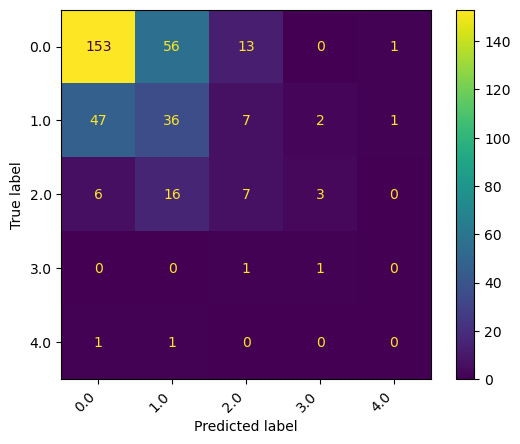

In [243]:
disp=ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
disp.ax_.set_xticklabels(disp.display_labels, rotation=45, ha='right')

In [245]:
y_test.value_counts()

Falls not rel to freezing past 12 months
0.0    223
1.0     93
2.0     32
3.0      2
4.0      2
Name: count, dtype: int64

In [264]:

injury_cols = [
    'FamilyHistory','No_of_years',
       'Bradykinesia present at diagnosis?',
       'Postural instability present at dx?',
       'Dopaminergic therapy started for participant', 'MoCA Total Score',
       'Freezing of gait in past 12 months',
       'lightheaded after standing', 'fainted',
       'Able to get on and off toilet', 'Able to step up and down curbs',
       'Able to get in and out of a car', 'Able to get out of bed into chair',
       'Able to run errands and shop', 'Able to get off floor without help',
       'Able to go for a walk of at least 15 min', 'Total Depression Score',
       'MDS-UPDRS PartIV score','BMI'
]

X_new = data11[injury_cols]
Y_new = data11['Falls not rel to freezing past 12 months']

In [249]:
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, Y_new, test_size = 0.3, random_state = 1)


In [251]:
#Importing all the libraries required
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score
tree_m = DecisionTreeClassifier(random_state = 1)
tree_m.fit(X_train_new, y_train_new)
y_pred_new = tree_m.predict(X_test_new)

#finding the accuracy of the descision tree on test data
accuracy = tree_m.score(X_test_new, y_test_new)
print("Accuracy of decision tree model: {:.2f}%".format(accuracy*100))
precision = precision_score(y_test_new, y_pred_new, average='weighted')
recall = recall_score(y_test_new, y_pred_new, average='weighted')
print(f"Precision for decision tree model: {precision:.2f}")
print(f"Recall for decision tree model: {recall:.2f}")

Accuracy of decision tree model: 62.50%
Precision for decision tree model: 0.65
Recall for decision tree model: 0.62


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


The optimal tree size: 5


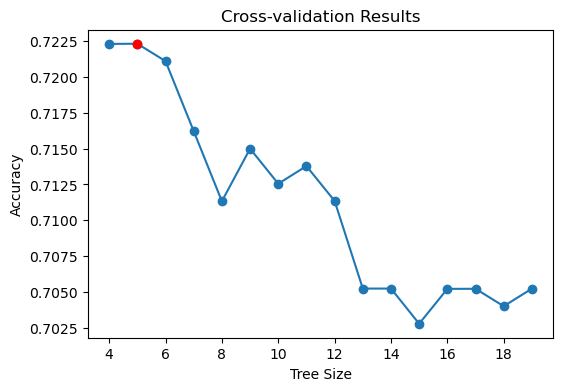

In [253]:
params = {'max_leaf_nodes': range(4, 20)}  
cv_tree_m = GridSearchCV(tree_m, params, cv=5)
cv_tree_m.fit(X_train_new, y_train_new)
cv_results_m = cv_tree_m.cv_results_

# find the best score for max leaf nodes
best_size = cv_tree_m.best_params_['max_leaf_nodes']
best_score = cv_tree_m.best_score_

# plot results of cross-validation
plt.figure(figsize=(6, 4))
plt.plot(cv_results_m["param_max_leaf_nodes"], cv_results_m["mean_test_score"], 'o-')
plt.plot(best_size, best_score, 'ro-')
plt.xlabel('Tree Size')
plt.ylabel('Accuracy')
plt.title('Cross-validation Results');
print('The optimal tree size:',best_size)

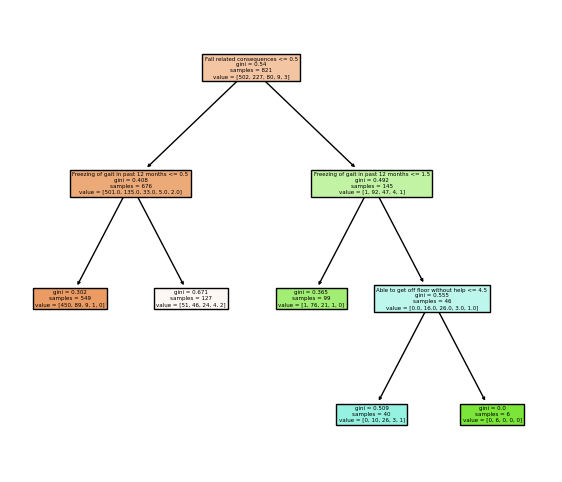

In [255]:
prune_tree_m = DecisionTreeClassifier(max_leaf_nodes=5, random_state=7)
prune_tree_m.fit(X_train_new, y_train_new)

# plot pruned tree
plt.figure(figsize=(7,6))
plt.title('Pruned Tree')
plot_tree(prune_tree_m, feature_names=X_train_new.columns, filled=True);

In [257]:
prune_tree_m.classes_


array([0., 1., 2., 3., 4.])

In [259]:
accuracy_tree_m = prune_tree_m.score(X_test_new,y_test_new)
print("Accuracy of the pruned tree in multi-class classifcation:",accuracy_tree_m)
y_pred_new = prune_tree_m.predict(X_test_new)
precision = precision_score(y_test_new, y_pred_new, average='weighted')
recall = recall_score(y_test_new, y_pred, average='weighted')
print(f"Precision for decision tree model: {precision:.2f}")
print(f"Recall for decision tree model: {recall:.2f}")

Accuracy of the pruned tree in multi-class classifcation: 0.7414772727272727
Precision for decision tree model: 0.73
Recall for decision tree model: 0.56


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [261]:
importances = pd.DataFrame({'feature_name': X_train_new.columns, 'importance': prune_tree_m.feature_importances_})
importances = importances.sort_values(by= ['importance'], ascending = False).reset_index(drop=True)
importances.head(10)

,feature_name,importance
0,Fall related consequences,0.705513
1,Freezing of gait in past 12 months,0.256492
2,Able to get off floor without help,0.037995
3,FamilyHistory,0.000000
4,Able to get in and out of a car,0.000000
5,MDS-UPDRS PartIV score,0.000000
6,Total Depression Score,0.000000
7,Able to go for a walk of at least 15 min,0.000000
8,Able to run errands and shop,0.000000
9,Able to get out of bed into chair,0.000000
